In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
 df = pd.read_csv('fake_reg.csv')

In [3]:
df.head()

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531


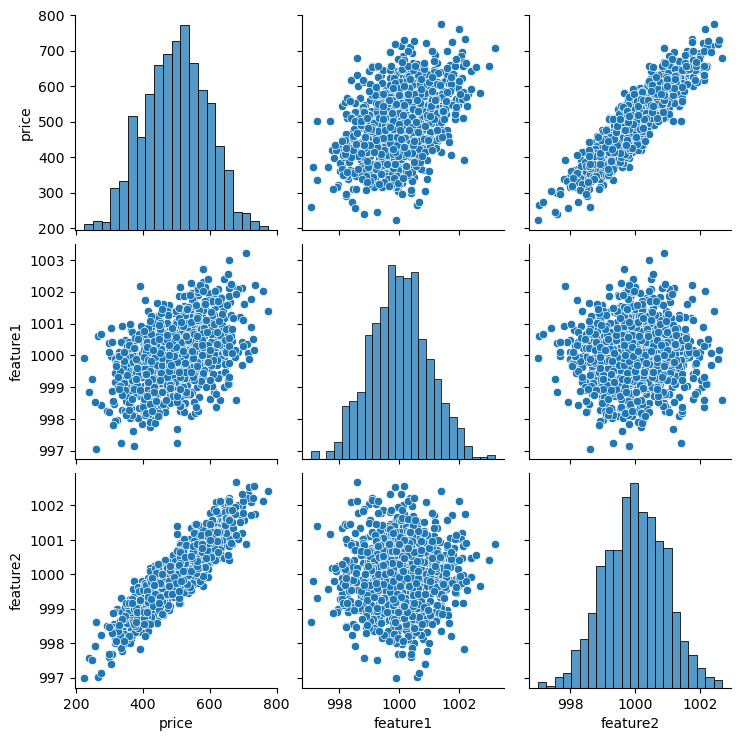

In [4]:
sns.pairplot(df)

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X = df[['feature1','feature2']].values

In [7]:
y = df['price'].values

In [8]:
#X

In [9]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
X_train.shape

(700, 2)

In [11]:
X_test.shape

(300, 2)

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
#help(MinMaxScaler)

In [14]:
scaler = MinMaxScaler()

In [15]:
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [16]:
X_train = scaler.transform(X_train)

In [17]:
X_test = scaler.transform(X_test)

In [18]:
X_train.min()

np.float64(0.0)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [20]:
model = Sequential()

In [21]:
model.add(Dense(4,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(1))

model.compile(optimizer='rmsprop',loss ='mse')

In [22]:
model.fit(x = X_train,y=y_train,epochs = 250)

Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 256692.9219   
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256637.7188 
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256582.9062 
Epoch 4/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256523.9844 
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256460.7344 
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256392.4375 
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256319.1250 
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256239.9844 
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256155.5156 
Epoch 10/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256064.3906 
Epoch 11/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255967.1250 
Epoch 12/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 255862.3125 
Epoch 13/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255750.0625 
Epoch 14/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

In [26]:
loss_df = pd.DataFrame(model.history.history)

<Axes: >

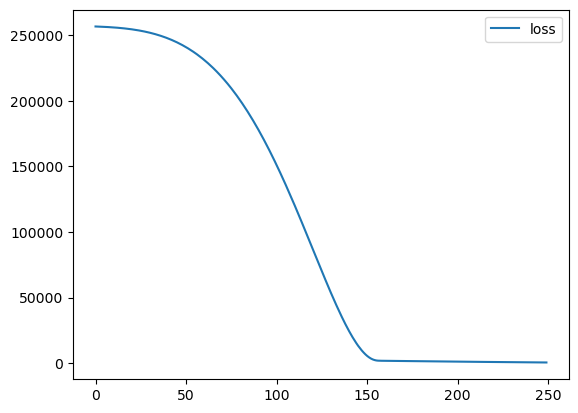

In [27]:
loss_df.plot()

In [28]:
model.evaluate(X_test, y_test, verbose = 0)

563.0881958007812

In [29]:
model.evaluate(X_train,y_train,verbose = 0)

577.5123291015625

In [34]:
test_predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [33]:
 #test_prediction

In [37]:
test_predictions = pd.Series(test_predictions.reshape(300,))


In [39]:
pred_df = pd.DataFrame(y_test,columns = ['Test True Y'])

In [40]:
pred_df = pd.concat([pred_df,test_predictions],axis = 1)

In [41]:
pred_df.columns=['Test True Y','Model Predictions']

<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

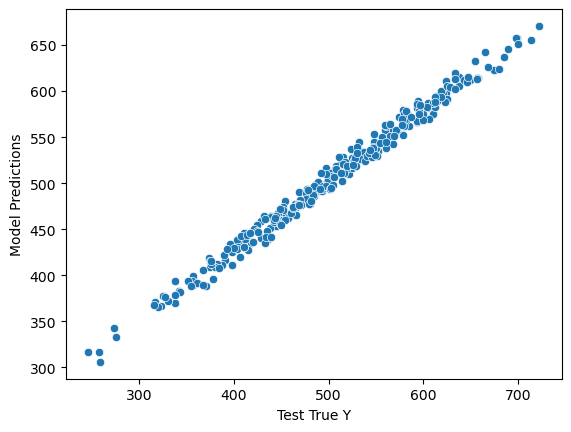

In [43]:
sns.scatterplot(x= 'Test True Y',y = 'Model Predictions',data= pred_df)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [49]:
mean_absolute_error(pred_df['Test True Y'],pred_df['Model Predictions'])**0.5

4.327872638089761

In [46]:
df

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531
...,...,...,...
995,476.526078,1000.018988,999.672732
996,457.313186,998.855379,1000.020026
997,456.720992,1001.451646,998.847606
998,403.315576,1000.771023,998.562851


In [50]:
#df.describe()

In [51]:
new_gem = [[998,1000]]

In [53]:
new_gem = scaler.transform(new_gem)

In [54]:
model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[430.18964]], dtype=float32)

In [55]:
from tensorflow.keras.models import load_model

In [65]:
model.save('my_model.keras')

In [68]:
later_model = load_model('my_model.keras')

In [69]:
later_model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[430.18964]], dtype=float32)